In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [6]:
df = pd.read_csv("Language Detection.csv")

df.head()

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (10337, 2)

Columns:
Index(['Text', 'Language'], dtype='object')

Missing Values:
Text        0
Language    0
dtype: int64


In [ ]:
df.dropna(inplace=True)

print(df.shape)

(10337, 2)


In [ ]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After removing duplicates:", df.shape)

Duplicates: 66
After removing duplicates: (10271, 2)


In [ ]:
df['Language'].value_counts()

,count
Language,
English,1382
French,1007
Spanish,816
Portugeese,736
Italian,694
Russian,688
Sweedish,673
Malayalam,591
Dutch,542


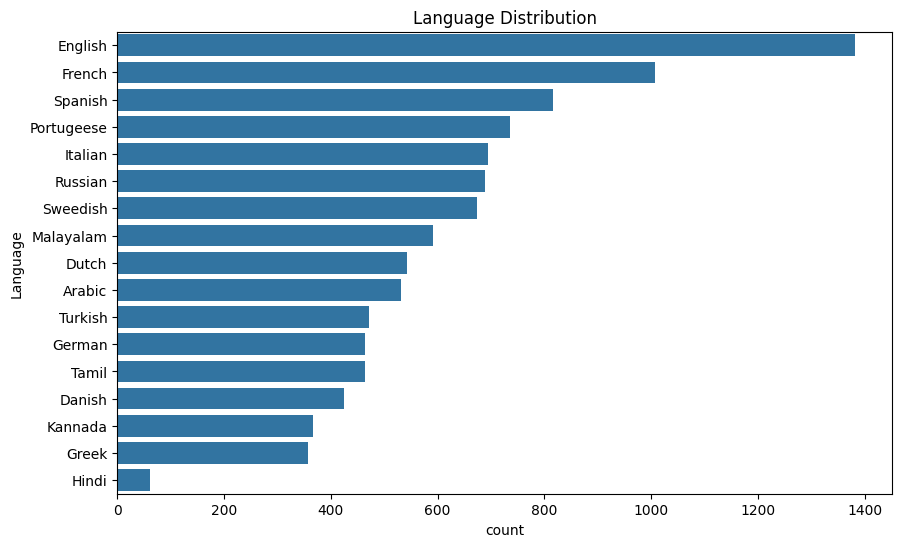

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=df['Language'],
    order=df['Language'].value_counts().index
)

plt.title("Language Distribution")
plt.show()

In [ ]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["Language"])

df.head()

,Text,Language,label
0,"Nature, in the broadest sense, is the natural...",English,3
1,"""Nature"" can refer to the phenomena of the phy...",English,3
2,"The study of nature is a large, if not the onl...",English,3
3,"Although humans are part of nature, human acti...",English,3
4,[1] The word nature is borrowed from the Old F...,English,3


In [ ]:
label_mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

label_mapping

{'Arabic': np.int64(0),
 'Danish': np.int64(1),
 'Dutch': np.int64(2),
 'English': np.int64(3),
 'French': np.int64(4),
 'German': np.int64(5),
 'Greek': np.int64(6),
 'Hindi': np.int64(7),
 'Italian': np.int64(8),
 'Kannada': np.int64(9),
 'Malayalam': np.int64(10),
 'Portugeese': np.int64(11),
 'Russian': np.int64(12),
 'Spanish': np.int64(13),
 'Sweedish': np.int64(14),
 'Tamil': np.int64(15),
 'Turkish': np.int64(16)}

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["Text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-multilingual-cased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
class LanguageDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[idx]
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = LanguageDataset(
    train_encodings,
    train_labels
)

test_dataset = LanguageDataset(
    test_encodings,
    test_labels
)

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=len(df["Language"].unique())
)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=3,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_dir="./logs",

    load_best_model_at_end=True
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.226340,0.073649
2,0.040612,0.045903
3,0.018028,0.057050


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1542, training_loss=0.0927180784878873, metrics={'train_runtime': 636.7945, 'train_samples_per_second': 38.706, 'train_steps_per_second': 2.422, 'total_flos': 1621508676802560.0, 'train_loss': 0.0927180784878873, 'epoch': 3.0})

In [ ]:
predictions = trainer.predict(test_dataset)

In [ ]:
preds = np.argmax(
    predictions.predictions,
    axis=1
)

In [ ]:
print(
    classification_report(
        test_labels,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       1.00      0.96      0.98        85
           2       1.00      1.00      1.00       108
           3       1.00      1.00      1.00       277
           4       0.99      0.99      0.99       202
           5       1.00      1.00      1.00        93
           6       1.00      1.00      1.00        72
           7       1.00      1.00      1.00        12
           8       1.00      0.98      0.99       139
           9       0.99      1.00      0.99        73
          10       1.00      1.00      1.00       118
          11       0.97      0.99      0.98       147
          12       1.00      0.99      0.99       138
          13       0.98      0.98      0.98       163
          14       0.99      1.00      0.99       135
          15       1.00      1.00      1.00        93
          16       0.98      1.00      0.99        94

    accuracy              

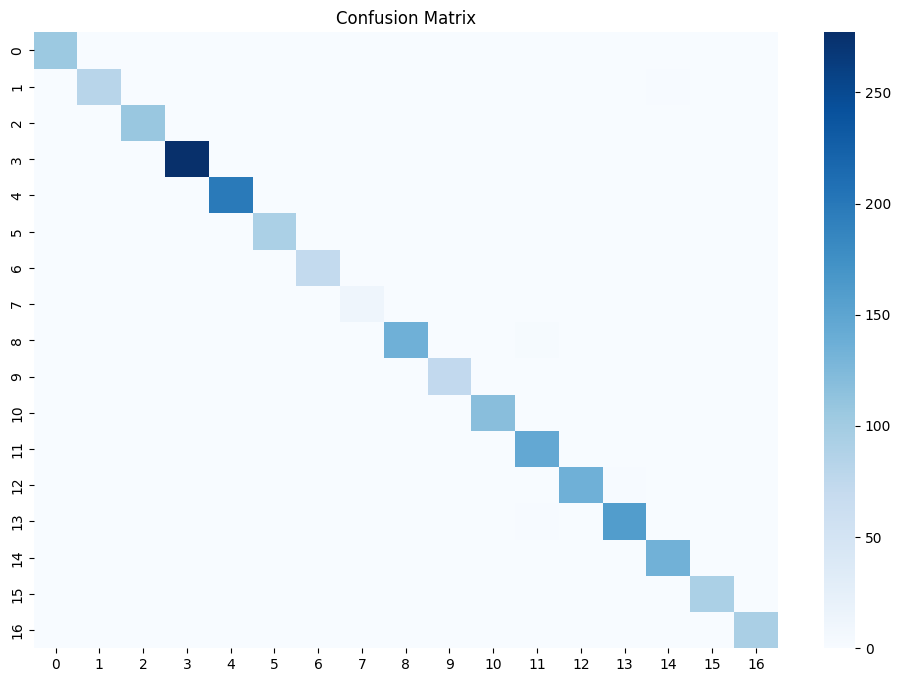

In [ ]:
cm = confusion_matrix(
    test_labels,
    preds
)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Sample text
sample = "ಇಂದು ಹವಾಮಾನ ತುಂಬಾ ಚೆನ್ನಾಗಿದೆ."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

inputs = tokenizer(
    sample,
    return_tensors="pt",
    truncation=True,
    padding=True
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

probs = torch.softmax(outputs.logits, dim=1)

prediction = torch.argmax(probs, dim=1).item()

confidence = probs[0][prediction].item() * 100

language = encoder.inverse_transform([prediction])[0]

print("Predicted Language:", language)
print(f"Confidence: {confidence:.2f}%")

Predicted Language: Kannada
Confidence: 99.81%


In [ ]:
!zip -r language_model.zip language_model

	zip warning: name not matched: language_model

zip error: Nothing to do! (try: zip -r language_model.zip . -i language_model)


In [ ]:
!ls

'Language Detection.csv'   results   sample_data


In [ ]:
model.save_pretrained("language_model")
tokenizer.save_pretrained("language_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('language_model/tokenizer_config.json', 'language_model/tokenizer.json')

In [ ]:
!ls language_model

config.json  model.safetensors	tokenizer_config.json  tokenizer.json


In [ ]:
!zip -r language_model.zip language_model

  adding: language_model/ (stored 0%)
  adding: language_model/tokenizer.json (deflated 67%)
  adding: language_model/tokenizer_config.json (deflated 44%)
  adding: language_model/model.safetensors (deflated 7%)
  adding: language_model/config.json (deflated 63%)


In [ ]:
from google.colab import files
files.download("language_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["Language"])

In [8]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [9]:
mapping = pd.DataFrame({
    "Language": encoder.classes_,
    "Label": range(len(encoder.classes_))
})

mapping.to_csv("label_mapping.csv", index=False)

mapping.head()

,Language,Label
0,Arabic,0
1,Danish,1
2,Dutch,2
3,English,3
4,French,4


In [10]:
from google.colab import files

files.download("label_mapping.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>